In [1]:
import pandas as pd
import numpy as np

In [2]:
file_path = "2026-04-MD.csv"  # coloque 2026-04-MD.csv na mesma pasta deste notebook
raw = pd.read_csv(file_path, header=None, low_memory=False)
print(f"Linhas brutas: {len(raw)}  |  Colunas: {raw.shape[1]}")
raw.iloc[:3, :5]

Linhas brutas: 809  |  Colunas: 127


,0,1,2,3,4
0,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx
1,Transform:,5,5,5,5
2,1/1/1959,2583.56,2426,15.188,276676.8154


In [3]:
# Linha 0: cabeçalho com nomes; Linha 1: 'Transform:' + tcodes; Linha 2+: dados
series_names = raw.iloc[0, 1:].tolist()           # nomes das séries
tcode = raw.iloc[1, 1:].astype(float).values      # array de tcodes

df = raw.iloc[2:].copy()
df.columns = ["date"] + series_names
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")
df = df.set_index("date")
df = df.apply(pd.to_numeric, errors="coerce")

print(f"Período: {df.index[0].date()} → {df.index[-1].date()}")
print(f"Séries: {df.shape[1]}  |  tcode únicos: {sorted(set(tcode.astype(int)))}")
df.head(3)

Período: 1959-01-01 → 2026-03-01
Séries: 126  |  tcode únicos: [np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2583.560,2426.0,15.188,276676.8154,17689.23968,21.9998,23.6312,22.5507,32.1377,19.7514,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
1959-02-01,2593.596,2434.8,15.346,278713.9773,17819.01912,22.4306,23.9501,22.7461,32.3734,19.8551,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
1959-03-01,2610.396,2452.7,15.491,277775.2539,17967.91336,22.7538,24.0951,22.8577,32.3734,20.2439,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN


In [4]:
def apply_tcode(series: pd.Series, code: int) -> pd.Series:
    """
    Aplica a transformação do FRED-MD para induzir estacionariedade.

    Referência: McCracken & Ng (2016), Appendix A.

    Códigos:
        1 - nível (sem transformação)
        2 - primeira diferença:           Δx_t
        3 - segunda diferença:            Δ²x_t
        4 - log:                          ln(x_t)
        5 - primeira diferença do log:    Δln(x_t)
        6 - segunda diferença do log:     Δ²ln(x_t)
        7 - diferença da taxa de cresc.:  Δ(x_t / x_{t-1} - 1)
    """
    x = series.copy()
    if code == 1:
        return x
    elif code == 2:
        return x.diff()
    elif code == 3:
        return x.diff().diff()
    elif code == 4:
        return np.log(x)
    elif code == 5:
        return np.log(x).diff()
    elif code == 6:
        return np.log(x).diff().diff()
    elif code == 7:
        return x.pct_change().diff()
    else:
        raise ValueError(f"tcode desconhecido: {code}")

In [5]:
transformed = {}
for col, code in zip(df.columns, tcode):
    transformed[col] = apply_tcode(df[col], int(code))

df_transformed = pd.DataFrame(transformed, index=df.index)
df_transformed.dropna(how="all", inplace=True)

print(f"Shape transformado: {df_transformed.shape}")
df_transformed.head(3)

Shape transformado: (807, 126)


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-02-01,0.003877,0.003621,0.010349,0.007336,0.007310,0.019393,0.013405,0.008628,0.007307,0.005237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-03-01,0.006457,0.007325,0.009404,-0.003374,0.008321,0.014306,0.006036,0.004894,0.000000,0.019393,...,-0.001148,0.000292,-0.000022,-0.008147,0.004819,NaN,0.004929,0.004138,-0.014792,NaN


In [6]:
df_transformed = df_transformed.loc["1965-01":]
print(f"Após corte (≥ 1965-01): {df_transformed.shape}")

Após corte (≥ 1965-01): (735, 126)


In [7]:
LATE_START = ["ACOGNO", "ANDENOx", "TWEXAFEGSMTHx"]
df_transformed = df_transformed.drop(columns=LATE_START)
print(f"Séries removidas (início tardio): {LATE_START}")
print(f"Shape após remoção: {df_transformed.shape}")

Séries removidas (início tardio): ['ACOGNO', 'ANDENOx', 'TWEXAFEGSMTHx']
Shape após remoção: (735, 123)


In [8]:
from sklearn.decomposition import PCA

def em_pca_impute(df: pd.DataFrame, r: int = 8, max_iter: int = 1000, tol: float = 1e-6) -> pd.DataFrame:
    """
    Imputação EM-PCA para dados com buracos internos.

    Algoritmo (Stock & Watson / McCracken & Ng):
      1. Padroniza cada série (média 0, std 1) ignorando NaNs.
      2. Inicializa NaNs com 0 (média padronizada).
      3. Loop EM:
           a. Ajusta PCA com r fatores na matriz completa.
           b. Reconstrói a matriz via projeção nos r PCs.
           c. Substitui apenas as posições originalmente NaN pela reconstrução.
           d. Verifica convergência pela variação relativa da norma de Frobenius.
      4. Reverte padronização.

    Parâmetros
    ----------
    df       : DataFrame com NaNs apenas em buracos internos.
    r        : número de fatores estáticos (padrão FRED-MD = 8).
    max_iter : máximo de iterações EM.
    tol      : tolerância de convergência.
    """
    X = df.values.copy().astype(float)
    nan_mask = np.isnan(X)

    col_means = np.nanmean(X, axis=0)
    col_stds  = np.nanstd(X, axis=0, ddof=1)
    col_stds[col_stds == 0] = 1.0

    X_std = (X - col_means) / col_stds
    X_std[nan_mask] = 0.0

    pca = PCA(n_components=r)
    prev_norm = np.inf

    for iteration in range(max_iter):
        X_hat = pca.fit(X_std).transform(X_std)
        X_reconstructed = pca.inverse_transform(X_hat)

        X_new = X_std.copy()
        X_new[nan_mask] = X_reconstructed[nan_mask]

        diff = np.linalg.norm(X_new - X_std, "fro")
        rel_change = diff / (prev_norm + 1e-12)

        X_std = X_new
        prev_norm = diff

        if rel_change < tol:
            print(f"EM-PCA convergiu em {iteration + 1} iterações (Δrel={rel_change:.2e})")
            break
    else:
        print(f"EM-PCA atingiu max_iter={max_iter} sem convergir (Δrel={rel_change:.2e})")

    X_imputed = X_std * col_stds + col_means
    return pd.DataFrame(X_imputed, index=df.index, columns=df.columns)


n_missing_before = df_transformed.isna().sum().sum()
print(f"NaNs antes da imputação: {n_missing_before}")

df_transformed = em_pca_impute(df_transformed, r=8)

n_missing_after = df_transformed.isna().sum().sum()
print(f"NaNs após imputação: {n_missing_after}")
print(f"Shape final: {df_transformed.shape}")

NaNs antes da imputação: 221
EM-PCA convergiu em 1 iterações (Δrel=0.00e+00)
NaNs após imputação: 0
Shape final: (735, 123)


In [9]:
df_standardized = (df_transformed - df_transformed.mean()) / df_transformed.std()
print(f"Shape padronizado: {df_standardized.shape}")
print(f"Média global (deve ser ≈ 0): {df_standardized.mean().mean():.6f}")
print(f"Std global (deve ser ≈ 1):   {df_standardized.std().mean():.6f}")
df_standardized.head(3)

Shape padronizado: (735, 123)
Média global (deve ser ≈ 0): 0.000000
Std global (deve ser ≈ 1):   1.000000


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1965-01-01,0.311185,-0.077923,0.563642,-1.089981,0.162619,0.952503,0.983421,0.880751,1.293890,0.472634,...,-0.077604,0.050833,-2.032020,-2.065924,-0.962134,0.090035,-0.102184,-0.708655,-1.020919,-1.339894
1965-02-01,-0.157962,0.503730,1.655165,0.119920,0.098736,0.477288,0.688922,0.446561,0.153682,0.362255,...,-0.281159,-0.002971,3.021507,3.694841,-0.002648,0.284084,0.120543,0.176567,-0.093333,-0.835098
1965-03-01,0.194243,0.423638,0.066017,1.351367,-0.934887,1.209125,1.055079,1.031057,0.756207,0.781207,...,0.476909,-0.323890,-2.020109,-2.462510,-0.002616,-0.245389,0.102641,0.009734,-0.051556,-1.297631


In [10]:
REGRESSION_SERIES = ["INDPRO", "CPIAUCSL", "FEDFUNDS", "T10YFFM", "S&P 500"]
df_regressao = df_standardized[REGRESSION_SERIES].copy()
df_regressao.to_csv("regressao.csv")
print(f"Salvo: regressao.csv  ({df_regressao.shape[0]} obs × {df_regressao.shape[1]} séries)")

df_standardized = df_standardized.drop(columns=REGRESSION_SERIES)
print(f"Séries removidas do conjunto principal: {REGRESSION_SERIES}")
print(f"Shape após remoção: {df_standardized.shape}")
df_regressao.head(3)

Salvo: regressao.csv  (735 obs × 5 séries)
Séries removidas do conjunto principal: ['INDPRO', 'CPIAUCSL', 'FEDFUNDS', 'T10YFFM', 'S&P 500']
Shape após remoção: (735, 118)


,INDPRO,CPIAUCSL,FEDFUNDS,T10YFFM,S&P 500
date,,,,,
1965-01-01,0.952503,-0.119502,0.099355,-0.407508,0.537003
1965-02-01,0.477288,-0.350257,0.158629,-0.443734,0.036979
1965-03-01,1.209125,0.343229,0.138871,-0.479961,-0.138792


In [11]:
# Salva o painel padronizado já SEM as 6 séries de regressão (evita circularidade
# entre a etapa de agrupamento e a etapa de caracterização econômica).
#
# Esse arquivo é lido de volta apenas como artefato de conferência (ex.: notebook
# de estacionariedade); dentro deste próprio notebook, as células seguintes usam
# `df_standardized` diretamente da memória — não há leitura de disco no meio do
# fluxo, o que antes causava um erro de ordem (célula de K-Means tentava ler este
# CSV antes de ele existir).
output_path = "fred_md_standardized.csv"
df_standardized.to_csv(output_path)
print(f"Arquivo salvo: {output_path}  ({df_standardized.shape[0]} obs × {df_standardized.shape[1]} séries)")

Arquivo salvo: fred_md_standardized.csv  (735 obs × 118 séries)


In [12]:
# --- 6ª série de referência da regressão: câmbio (TWEXAFEGSMTHx) ---
#
# TWEXAFEGSMTHx foi excluída do painel principal em LATE_START (início em
# 1973-01, não 1965-01, o que forçaria todo o painel de agrupamento a perder
# 8 anos de observações só por causa de uma série que nem entra no clustering).
# Como ela NÃO é usada no K-Means, isso não compromete a etapa de agrupamento.
#
# Decisão tomada agora, ANTES de rodar qualquer regressão (não depois de ver
# resultados): o câmbio entra como 6º alvo de regressão porque é a série de
# referência de câmbio prevista na metodologia (etapa 5). A consequência —
# assumida aqui, não descoberta depois — é que a janela temporal de TODAS as
# regressões por cluster fica restrita ao período em que o câmbio existe
# (~1973 em diante), já que a regressão é multivariada com os 6 alvos
# simultaneamente. Isso é reportado explicitamente no shape de X_reg abaixo.

serie_cambio_bruta = df["TWEXAFEGSMTHx"]          # série bruta, pré-tcode (célula de montagem do df)
serie_cambio = apply_tcode(serie_cambio_bruta, 5)  # tcode=5: Δln(x), mesmo código do FRED-MD
serie_cambio = serie_cambio.dropna()               # a diferença log perde a 1ª observação

# Padronização com média/desvio PRÓPRIOS da série (não os do painel 1965+,
# que nem cobrem o período em que o câmbio está disponível)
serie_cambio = (serie_cambio - serie_cambio.mean()) / serie_cambio.std()
serie_cambio.name = "TWEXAFEGSMTHx"

print(f"Câmbio (TWEXAFEGSMTHx) — tcode=5, padronizado individualmente")
print(f"Período: {serie_cambio.index[0].date()} → {serie_cambio.index[-1].date()}  ({len(serie_cambio)} obs)")
serie_cambio.head(3)

Câmbio (TWEXAFEGSMTHx) — tcode=5, padronizado individualmente
Período: 1973-02-01 → 2026-03-01  (638 obs)


date
1973-02-01   -2.525123
1973-03-01   -2.213374
1973-04-01    0.510104
Name: TWEXAFEGSMTHx, dtype: float64

In [13]:
# --- Dataset final de regressão (6 séries de referência) ---
#
# join "inner" nas datas: a regressão por cluster (etapa 5) precisa das 6
# séries simultaneamente na mesma linha de tempo, então a janela comum é
# necessariamente a interseção — limitada por baixo pela disponibilidade do
# câmbio (~1973), não pelas outras 5 séries (que cobrem 1965+).
X_reg = df_regressao.join(serie_cambio, how="inner")

print(f"Shape de X_reg: {X_reg.shape[0]} obs × {X_reg.shape[1]} séries")
print(f"Janela de datas: {X_reg.index[0].date()} → {X_reg.index[-1].date()}")
X_reg.head(3)

Shape de X_reg: 638 obs × 6 séries
Janela de datas: 1973-02-01 → 2026-03-01


,INDPRO,CPIAUCSL,FEDFUNDS,T10YFFM,S&P 500,TWEXAFEGSMTHx
date,,,,,,
1973-02-01,1.318921,0.830484,1.265078,-0.546375,-1.161320,-2.525123
1973-03-01,-0.123606,0.813051,1.008224,-0.812035,-0.602835,-2.213374
1973-04-01,-0.329947,-0.860431,0.059839,-0.854299,-0.684900,0.510104


In [14]:
from scipy import stats

# --- Teste de Esfericidade de Bartlett ---
# H₀: a matriz de correlação é a identidade (variáveis completamente independentes).
# Rejeitar H₀ (p < 0,05) indica correlações suficientes para análise fatorial.
#
# Estatística: χ² = −[n − 1 − (2p + 5)/6] · ln|R|
# onde n = nº de observações, p = nº de variáveis, R = matriz de correlação.

X = df_standardized.values
n, p = X.shape

R = np.corrcoef(X, rowvar=False)
sign, log_det = np.linalg.slogdet(R)

chi2_stat = -(n - 1 - (2 * p + 5) / 6) * log_det
df_chi2   = p * (p - 1) / 2
p_value   = stats.chi2.sf(chi2_stat, df=df_chi2)

print("=" * 50)
print("Teste de Esfericidade de Bartlett")
print("=" * 50)
print(f"  χ²       = {chi2_stat:,.2f}")
print(f"  gl       = {int(df_chi2):,}")
print(f"  p-valor  = {p_value:.2e}")
print()
if p_value < 0.05:
    print("  → Rejeita H₀: há correlações significativas entre as variáveis.")
    print("    A matriz de correlação NÃO é identidade. ✅ Prosseguir com análise fatorial.")
else:
    print("  → Não rejeita H₀: variáveis podem ser independentes. ⚠️ Revisar dados.")

Teste de Esfericidade de Bartlett
  χ²       = 135,949.20
  gl       = 6,903
  p-valor  = 0.00e+00

  → Rejeita H₀: há correlações significativas entre as variáveis.
    A matriz de correlação NÃO é identidade. ✅ Prosseguir com análise fatorial.


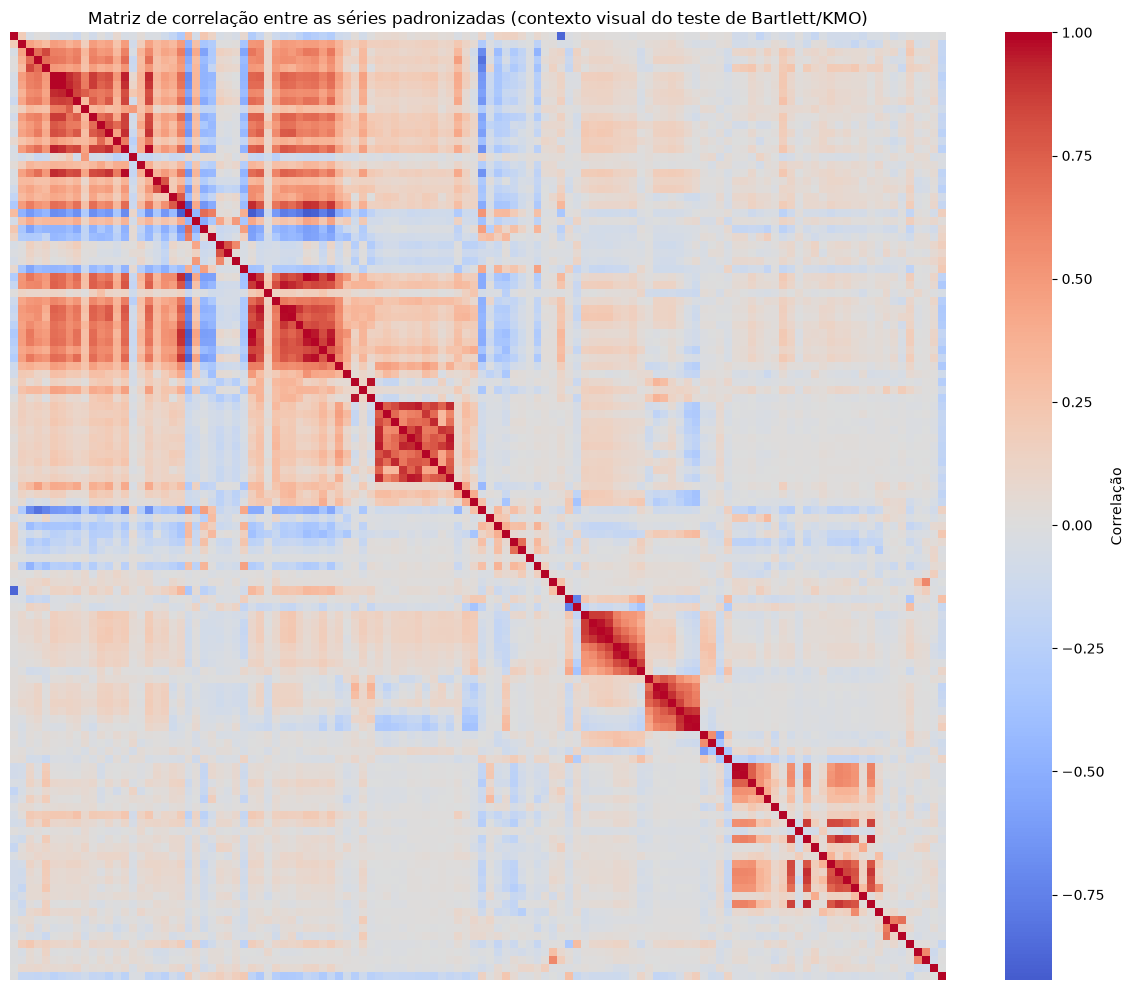

Figura salva: correlation_heatmap.png


In [15]:
# --- Visualização: matriz de correlação entre as séries ---
# Contexto visual por trás do teste de Bartlett e do KMO (célula seguinte):
# o heatmap mostra a estrutura de correlação entre as 118 séries que
# justifica prosseguir para análise fatorial (blocos de séries fortemente
# correlacionadas entre si, fora da diagonal). Sem anotação de valores —
# com ~118 séries, anotar cada célula tornaria o heatmap ilegível; o que
# importa aqui é o padrão visual (blocos de cor), não o valor exato de
# cada célula.
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    pd.DataFrame(R, index=df_standardized.columns, columns=df_standardized.columns),
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Correlação"},
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)
ax.set_title("Matriz de correlação entre as séries padronizadas (contexto visual do teste de Bartlett/KMO)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Figura salva: correlation_heatmap.png")


In [16]:
try:
    from factor_analyzer.factor_analyzer import calculate_kmo
    kmo_per_variable, kmo_global = calculate_kmo(df_standardized)
    kmo_source = "factor_analyzer"
except ImportError:
    # Implementação manual via matriz de correlação anti-imagem
    # KMO_j = Σ_{k≠j} r²_jk / (Σ_{k≠j} r²_jk + Σ_{k≠j} q²_jk)
    # onde Q = −diag(R⁻¹)^{-1/2} · R⁻¹ · diag(R⁻¹)^{-1/2}  (correlações parciais)
    R_inv = np.linalg.inv(R)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(R_inv)))
    partial_corr = -D_inv_sqrt @ R_inv @ D_inv_sqrt
    np.fill_diagonal(partial_corr, 0)
    np.fill_diagonal(R, 0)

    r2 = R ** 2
    q2 = partial_corr ** 2
    kmo_per_variable = r2.sum(axis=1) / (r2.sum(axis=1) + q2.sum(axis=1))
    kmo_global = r2.sum() / (r2.sum() + q2.sum())

    np.fill_diagonal(R, 1)  # restaura diagonal

# --- Interpretação KMO ---
def kmo_label(k):
    if k >= 0.90: return "Maravilhoso"
    elif k >= 0.80: return "Meritório"
    elif k >= 0.70: return "Mediano"
    elif k >= 0.60: return "Medíocre"
    elif k >= 0.50: return "Miserável"
    else: return "Inaceitável"

print("=" * 50)
print(f"Kaiser-Meyer-Olkin (KMO)")
print("=" * 50)
print(f"  KMO global = {kmo_global:.4f}  →  {kmo_label(kmo_global)}")
print()

kmo_series = pd.Series(kmo_per_variable, index=df_standardized.columns, name="KMO")
print(f"  Variáveis com KMO < 0,50 (problemáticas): "
      f"{(kmo_series < 0.50).sum()}")
print(f"  Variáveis com KMO ≥ 0,90 (maravilhosas):  "
      f"{(kmo_series >= 0.90).sum()}")
print()

if kmo_global >= 0.50:
    print(f"\n  → KMO = {kmo_global:.4f} ≥ 0,50. ✅ Dados fatoráveis.")
else:
    print(f"\n  → KMO = {kmo_global:.4f} < 0,50. ⚠️ Dados não fatoráveis.")

Kaiser-Meyer-Olkin (KMO)
  KMO global = 0.8039  →  Meritório

  Variáveis com KMO < 0,50 (problemáticas): 15
  Variáveis com KMO ≥ 0,90 (maravilhosas):  24


  → KMO = 0.8039 ≥ 0,50. ✅ Dados fatoráveis.


/media/doald533/HD/github/compsci-squad/tcc2/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [17]:
# Roda PCA completo sobre df_standardized.
# k = número mínimo de componentes que cobre ≥ 70% da variância total.

pca_full    = PCA().fit(df_standardized)
explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

# Critério principal: ≥ 70% de variância acumulada
k_70 = int(np.argmax(cumulative >= 0.70)) + 1


print("=" * 55)
print("Análise de Componentes Principais — Seleção de k")
print("=" * 55)
print(f"  PC1 explica              : {explained[0]*100:.1f}% da variância total")
print(f"  k (≥ 70% acumulado)      : {k_70}  componentes → {cumulative[k_70-1]*100:.1f}%")
print()
print(f"  ► K adotado para k-means : {k_70}")
print()

# Tabela dos primeiros 19 componentes
n_show = 19
summary_pca = pd.DataFrame({
    "variancia_%":   explained[:n_show] * 100,
    "acumulada_%":   cumulative[:n_show] * 100,
}, index=range(1, n_show + 1))
summary_pca.index.name = "PC"
print(summary_pca.round(2).to_string())

Análise de Componentes Principais — Seleção de k
  PC1 explica              : 19.6% da variância total
  k (≥ 70% acumulado)      : 19  componentes → 70.2%

  ► K adotado para k-means : 19

    variancia_%  acumulada_%
PC                          
1         19.55        19.55
2          7.49        27.05
3          6.74        33.78
4          5.49        39.27
5          4.89        44.16
6          3.34        47.50
7          2.52        50.02
8          2.41        52.43
9          2.11        54.54
10         1.89        56.44
11         1.87        58.31
12         1.73        60.03
13         1.71        61.74
14         1.63        63.37
15         1.58        64.95
16         1.43        66.38
17         1.34        67.72
18         1.27        68.99
19         1.21        70.20


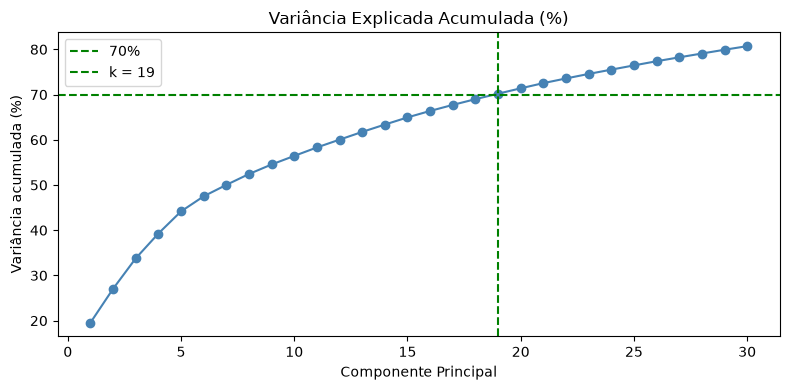

Figura salva: scree_plot.png  |  K adotado para k-means = 19


In [18]:
import matplotlib.pyplot as plt

n_show = 30
comp   = range(1, n_show + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(comp, cumulative[:n_show] * 100, marker="o", color="steelblue")
ax.axhline(70, color="green",   linestyle="--", label="70%")
ax.axvline(k_70, color="green", linestyle="--", label=f"k = {k_70}")
ax.set_title("Variância Explicada Acumulada (%)")
ax.set_xlabel("Componente Principal")
ax.set_ylabel("Variância acumulada (%)")
ax.legend()

plt.tight_layout()
plt.savefig("scree_plot.png", dpi=150)
plt.show()
print(f"Figura salva: scree_plot.png  |  K adotado para k-means = {k_70}")

In [19]:
from sklearn.cluster import KMeans

# Usa df_standardized já em memória (painel padronizado, sem as 6 séries de
# regressão) — não relê do disco. O CSV salvo antes (fred_md_standardized.csv)
# é apenas um artefato de conferência; reler aqui criava uma dependência de
# ordem de execução desnecessária (e, antes desta correção, um bug real: essa
# leitura apontava para um arquivo que só era criado na última célula do
# notebook).
print(f"Shape em memória: {df_standardized.shape}  ({df_standardized.shape[0]} obs × {df_standardized.shape[1]} séries)")

# Transpõe: cada série vira um ponto em R^T (espaço temporal)
X = df_standardized.T.values
series_names = df_standardized.columns.tolist()
print(f"Shape para clustering (séries × obs): {X.shape}")

# K definido pelo critério de 70% de variância explicada acumulada (Passo 3)
K = 19

kmeans = KMeans(
    n_clusters=K,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42,
)
kmeans.fit(X)

labels = kmeans.labels_
inertia = kmeans.inertia_

print(f"K-Means concluído.")
print(f"  k          = {K}")
print(f"  Inércia    = {inertia:,.2f}")
print(f"  Iterações  = {kmeans.n_iter_}")

# Monta DataFrame com resultado
clusters = pd.DataFrame({
    "serie":   series_names,
    "cluster": labels,
}).sort_values(["cluster", "serie"]).reset_index(drop=True)

clusters.to_csv("clusters.csv", index=False)
print(f"Salvo: clusters.csv  ({len(clusters)} séries × 2 colunas)")
clusters

# Tabela: séries por grupo
print("Séries por cluster:\n")
for g in sorted(clusters["cluster"].unique()):
    membros = clusters.loc[clusters["cluster"] == g, "serie"].tolist()
    print(f"  Cluster {g:2d} ({len(membros):2d} séries): {', '.join(membros)}")

Shape em memória: (735, 118)  (735 obs × 118 séries)
Shape para clustering (séries × obs): (118, 735)
K-Means concluído.
  k          = 19
  Inércia    = 36,807.68
  Iterações  = 4
Salvo: clusters.csv  (118 séries × 2 colunas)
Séries por cluster:

  Cluster  0 ( 7 séries): AAAFFM, BAAFFM, COMPAPFFx, T1YFFM, T5YFFM, TB3SMFFM, TB6SMFFM
  Cluster  1 (13 séries): AMDMNOx, AWOTMAN, CMRMTSPLx, CUMFNS, IPBUSEQ, IPCONGD, IPDCONGD, IPDMAT, IPFINAL, IPFPNSS, IPMANSICS, IPMAT, IPNMAT
  Cluster  2 (10 séries): HOUST, HOUSTMW, HOUSTNE, HOUSTS, HOUSTW, PERMIT, PERMITMW, PERMITNE, PERMITS, PERMITW
  Cluster  3 ( 5 séries): BUSLOANS, CLAIMSx, ISRATIOx, UEMPLT5, UNRATE
  Cluster  4 ( 8 séries): AAA, BAA, CP3Mx, GS1, GS10, GS5, TB3MS, TB6MS
  Cluster  5 ( 2 séries): IPB51222S, IPNCONGD
  Cluster  6 ( 7 séries): M1SL, OILPRICEx, PPICMM, WPSFD49207, WPSFD49502, WPSID61, WPSID62
  Cluster  7 ( 6 séries): AMDMUOx, AWHMAN, BUSINVx, CES0600000007, CES1021000001, EXUSUKx
  Cluster  8 ( 3 séries): DTCOLNVHFNM, 

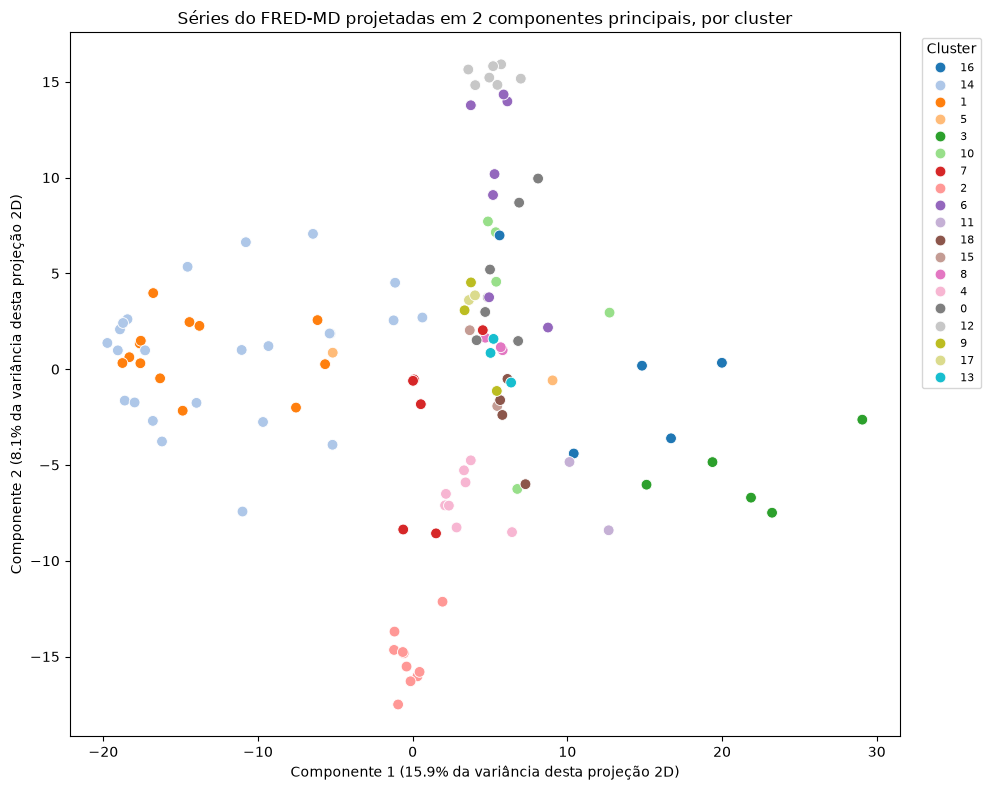

Figura salva: clusters_pca_scatter.png


In [20]:
# --- Visualização: séries no espaço PCA 2D, coloridas por cluster ---
# Projeta cada série (X = df_standardized.T.values, já em memória da célula
# de K-Means: linhas = séries, colunas = tempo) nos 2 primeiros componentes
# principais só para permitir uma visualização 2D dos clusters. Esse PCA(2)
# é diferente do `pca_full` usado para escolher k: aquele roda sobre
# df_standardized sem transpor (observações = datas) e usa todos os
# componentes para variância explicada; este aqui é só para plotar as
# séries no plano, com apenas 2 componentes.
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(X)  # X = df_standardized.T.values (séries x tempo)

df_plot = pd.DataFrame({
    "PC1": coords_2d[:, 0],
    "PC2": coords_2d[:, 1],
    "cluster": labels.astype(str),
})

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    data=df_plot, x="PC1", y="PC2", hue="cluster",
    palette="tab20", s=60, ax=ax,
)
ax.set_title("Séries do FRED-MD projetadas em 2 componentes principais, por cluster")
ax.set_xlabel(f"Componente 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% da variância desta projeção 2D)")
ax.set_ylabel(f"Componente 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% da variância desta projeção 2D)")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("clusters_pca_scatter.png", dpi=150)
plt.show()
print("Figura salva: clusters_pca_scatter.png")


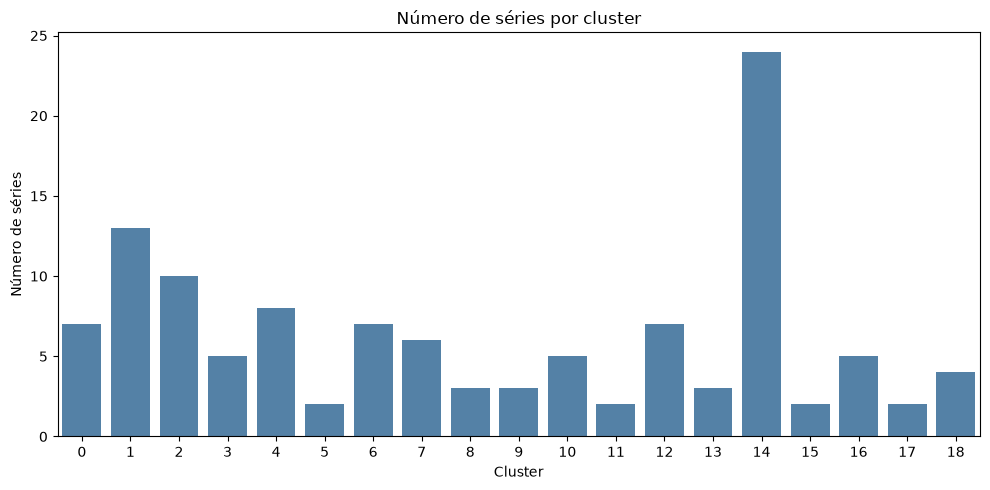

Figura salva: cluster_sizes.png


In [21]:
# --- Visualização: tamanho de cada cluster ---
# Mostra quantas séries cada cluster reuniu. Clusters muito desbalanceados
# (ex. um cluster com 24 séries vs. outros com apenas 2) são informação
# relevante para avaliar o K-Means — não é decoração, é o retrato direto de
# quão heterogênea ficou a partição.
cluster_sizes = clusters["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, color="steelblue", ax=ax)
ax.set_title("Número de séries por cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Número de séries")
plt.tight_layout()
plt.savefig("cluster_sizes.png", dpi=150)
plt.show()
print("Figura salva: cluster_sizes.png")


In [22]:
# --- Etapa 5: caracterização econômica dos clusters (regressão + diagnóstico) ---
#
# Para cada cluster, regride o centroide (série representativa do grupo no
# espaço temporal) contra as 6 séries de referência. Durbin-Watson
# (autocorrelação de 1ª ordem) e Breusch-Godfrey (autocorrelação de ordem
# superior) são reportados para TODO cluster, não só quando "der problema".
# nlags=4 no Breusch-Godfrey é uma escolha a priori (≈ 1 trimestre de defasagem
# para dados mensais), não um valor obtido tentando vários nlags e escolhendo
# o que "deu melhor" depois de ver o resultado.
#
# CORREÇÃO (feita depois de rodar o diagnóstico, não decisão prévia): o
# próprio Breusch-Godfrey rodado abaixo rejeita H0 (ausência de autocorrelação
# nos resíduos) em TODOS os 19 clusters. Isso invalida a hipótese de erros
# i.i.d. exigida pelo erro-padrão clássico do OLS — os p-valores/estatística F
# calculados com esse erro-padrão não são confiáveis num painel mensal com
# autocorrelação forte. Por isso o modelo é ajustado com erro-padrão HAC
# (Newey-West), robusto a heterocedasticidade e autocorrelação, usando o
# mesmo maxlags=BG_NLAGS do teste de Breusch-Godfrey (mesma justificativa de
# ~1 trimestre de defasagem para dados mensais, mantendo a defasagem
# consistente entre diagnóstico e correção). Isso é o comportamento esperado
# do diagnóstico: ele existe para mudar a análise quando acusa problema — é
# diferente de ajustar um parâmetro só porque não gostamos do resultado.
# Os coeficientes (modelo.params) e R² não mudam (dependem só de X'X e X'y,
# não do estimador de variância); o que muda são os erros-padrão e, portanto,
# p-valores e a estatística F.
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

BG_NLAGS = 4
reg_vars = X_reg.columns.tolist()

linhas_regressao = []
for cluster_id in sorted(clusters["cluster"].unique()):
    # Centroide do cluster no espaço temporal: kmeans foi ajustado sobre
    # X = df_standardized.T.values (linhas = séries, colunas = datas), então
    # cada cluster_centers_[cluster_id] é um vetor com um valor por DATA —
    # ou seja, indexado por df_standardized.index (não .columns, que são os
    # nomes das séries).
    y_full = pd.Series(kmeans.cluster_centers_[cluster_id], index=df_standardized.index)
    y_full.index = pd.to_datetime(y_full.index)

    # Restringe à janela comum das 6 séries de regressão (interseção de datas)
    datas_comuns = y_full.index.intersection(X_reg.index)
    y = y_full.loc[datas_comuns]
    X_c = X_reg.loc[datas_comuns]

    # Erro-padrão HAC (Newey-West), não o OLS clássico: ver justificativa no
    # comentário da célula (Breusch-Godfrey rejeitou resíduos i.i.d. em todos
    # os clusters).
    modelo = sm.OLS(y, sm.add_constant(X_c)).fit(
        cov_type="HAC", cov_kwds={"maxlags": BG_NLAGS}
    )

    dw = durbin_watson(modelo.resid)
    bg_stat, bg_pvalue, _, _ = acorr_breusch_godfrey(modelo, nlags=BG_NLAGS)

    linha = {
        "cluster": cluster_id,
        "n_obs": int(modelo.nobs),
        "r_squared": modelo.rsquared,
        "f_stat": modelo.fvalue,
        "f_pvalue": modelo.f_pvalue,
        "durbin_watson": dw,
        "bg_stat": bg_stat,
        "bg_pvalue": bg_pvalue,
    }
    for var in ["const"] + reg_vars:
        linha[f"coef_{var}"] = modelo.params.get(var, np.nan)
        linha[f"pvalue_{var}"] = modelo.pvalues.get(var, np.nan)

    linhas_regressao.append(linha)

resultados_regressao = pd.DataFrame(linhas_regressao)
resultados_regressao.to_csv("regressao_resultados.csv", index=False)

print(f"Janela comum usada em todas as regressões: {X_reg.index[0].date()} → {X_reg.index[-1].date()}")
print(f"Erro-padrão: HAC (Newey-West), maxlags={BG_NLAGS} — ver justificativa no comentário da célula")
print(f"Salvo: regressao_resultados.csv  ({resultados_regressao.shape[0]} clusters × {resultados_regressao.shape[1]} colunas)")
print()
print("Resumo por cluster:")
for _, row in resultados_regressao.iterrows():
    pvals_vars = {v: row[f"pvalue_{v}"] for v in reg_vars}
    var_menor_p = min(pvals_vars, key=pvals_vars.get)
    print(
        f"  Cluster {int(row['cluster']):2d}  "
        f"R²={row['r_squared']:.3f}  DW={row['durbin_watson']:.2f}  "
        f"BG p={row['bg_pvalue']:.3f}  "
        f"menor p-valor: {var_menor_p} (p={pvals_vars[var_menor_p]:.3g})"
    )

Janela comum usada em todas as regressões: 1973-02-01 → 2026-03-01
Erro-padrão: HAC (Newey-West), maxlags=4 — ver justificativa no comentário da célula
Salvo: regressao_resultados.csv  (19 clusters × 22 colunas)

Resumo por cluster:
  Cluster  0  R²=0.843  DW=0.35  BG p=0.000  menor p-valor: T10YFFM (p=6.14e-77)
  Cluster  1  R²=0.932  DW=2.34  BG p=0.000  menor p-valor: INDPRO (p=6.45e-190)
  Cluster  2  R²=0.100  DW=0.12  BG p=0.000  menor p-valor: INDPRO (p=0.00913)
  Cluster  3  R²=0.476  DW=2.13  BG p=0.000  menor p-valor: INDPRO (p=0.0017)
  Cluster  4  R²=0.455  DW=1.65  BG p=0.000  menor p-valor: FEDFUNDS (p=1.1e-22)
  Cluster  5  R²=0.098  DW=2.51  BG p=0.000  menor p-valor: INDPRO (p=0.000251)
  Cluster  6  R²=0.313  DW=2.90  BG p=0.000  menor p-valor: CPIAUCSL (p=6.42e-20)
  Cluster  7  R²=0.171  DW=0.50  BG p=0.000  menor p-valor: TWEXAFEGSMTHx (p=7.48e-08)
  Cluster  8  R²=0.013  DW=2.89  BG p=0.000  menor p-valor: CPIAUCSL (p=0.0426)
  Cluster  9  R²=0.087  DW=2.85  BG p=

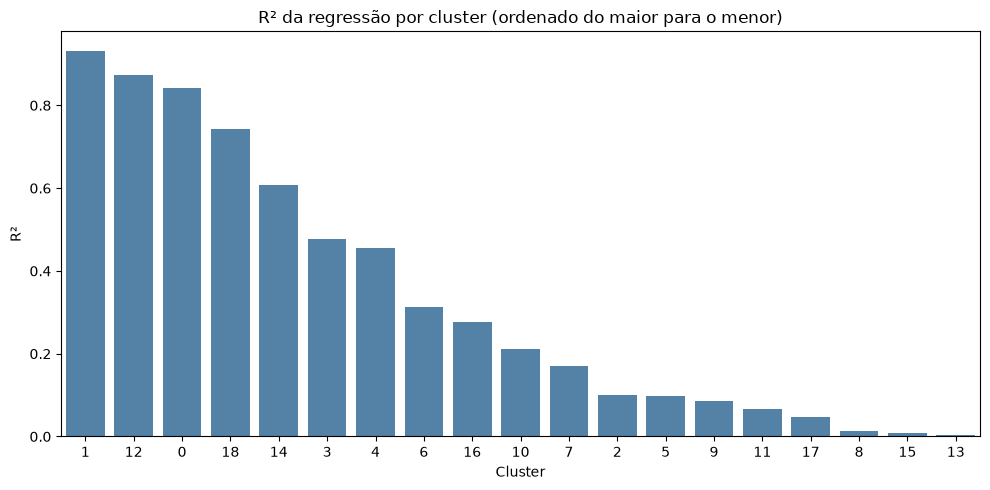

Figura salva: r2_por_cluster.png


In [23]:
# --- Visualização: R² por cluster ---
# Ordena os clusters do maior para o menor R² da regressão do centroide
# contra as 6 séries de referência. Mostra diretamente quais centróides são
# mais/menos explicados linearmente pelas variáveis de referência — sem
# atribuir interpretação econômica aqui (isso fica para a etapa de
# rotulagem, à parte).
r2_sorted = resultados_regressao[["cluster", "r_squared"]].sort_values("r_squared", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=r2_sorted["cluster"].astype(str),
    y=r2_sorted["r_squared"],
    order=r2_sorted["cluster"].astype(str),
    color="steelblue",
    ax=ax,
)
ax.set_title("R² da regressão por cluster (ordenado do maior para o menor)")
ax.set_xlabel("Cluster")
ax.set_ylabel("R²")
plt.tight_layout()
plt.savefig("r2_por_cluster.png", dpi=150)
plt.show()
print("Figura salva: r2_por_cluster.png")


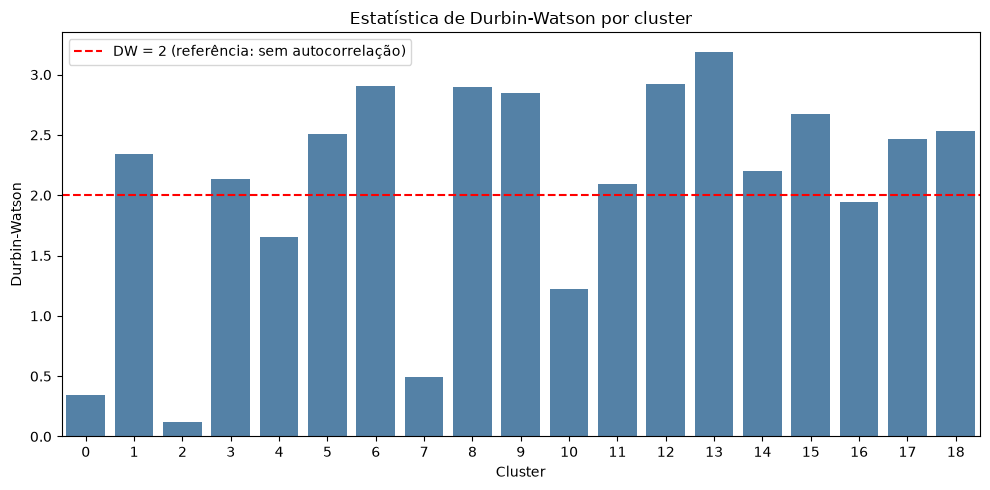

Figura salva: durbin_watson_por_cluster.png


In [24]:
# --- Visualização: Durbin-Watson por cluster ---
# DW = 2 é a referência teórica de "sem autocorrelação de 1ª ordem nos
# resíduos"; DW < 2 indica autocorrelação positiva, DW > 2 autocorrelação
# negativa. A linha tracejada em 2 deixa visualmente explícito que a
# maioria dos clusters fica longe dela — achado já documentado como
# limitação genuína da caracterização via OLS num painel mensal
# autocorrelacionado (ver também Breusch-Godfrey na célula da regressão),
# não um bug de execução.
dw_sorted = resultados_regressao[["cluster", "durbin_watson"]].sort_values("cluster")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=dw_sorted["cluster"].astype(str),
    y=dw_sorted["durbin_watson"],
    color="steelblue",
    ax=ax,
)
ax.axhline(2, color="red", linestyle="--", label="DW = 2 (referência: sem autocorrelação)")
ax.set_title("Estatística de Durbin-Watson por cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Durbin-Watson")
ax.legend()
plt.tight_layout()
plt.savefig("durbin_watson_por_cluster.png", dpi=150)
plt.show()
print("Figura salva: durbin_watson_por_cluster.png")


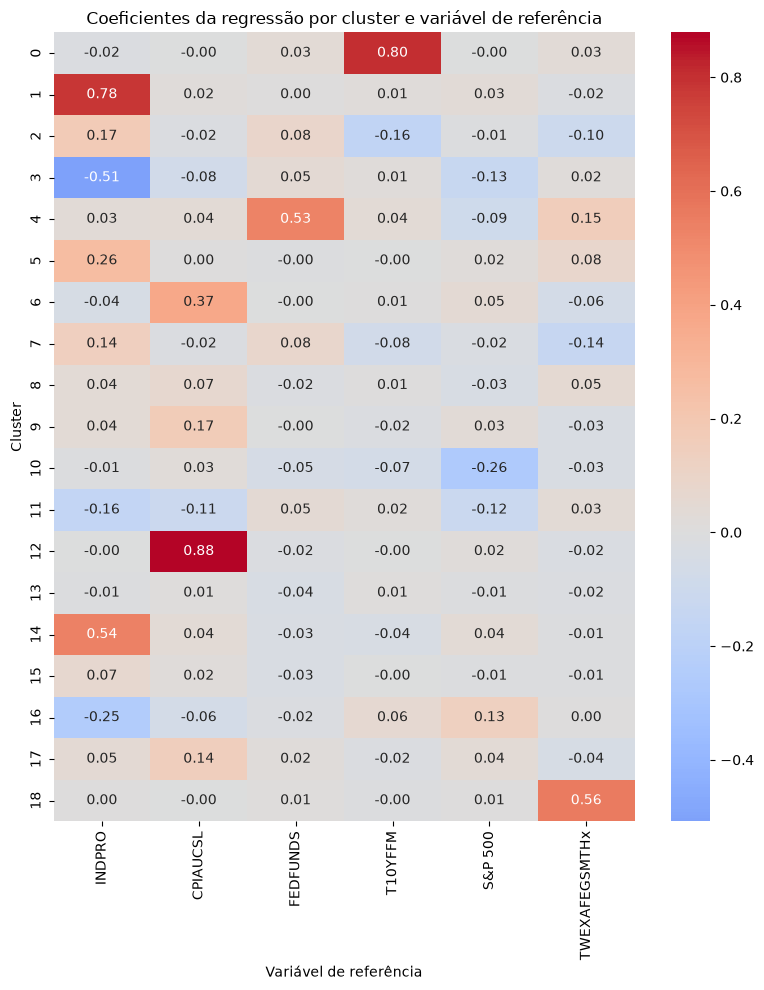

Figura salva: coeficientes_heatmap.png


In [25]:
# --- Visualização: coeficientes da regressão (cluster x variável de referência) ---
# Versão em imagem da mesma informação de "qual variável de referência
# domina qual cluster" que já está em texto em clusters_rotulados.csv
# (coluna variavel_dominante). Usa os coeficientes estimados (coef_<var>),
# não os p-valores, e exclui a constante — 19 clusters x 6 variáveis = 114
# células, cabe anotar com o valor exato em cada uma.
coef_cols = [f"coef_{v}" for v in reg_vars]
coef_matrix = resultados_regressao.set_index("cluster")[coef_cols]
coef_matrix.columns = reg_vars

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(coef_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Coeficientes da regressão por cluster e variável de referência")
ax.set_xlabel("Variável de referência")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("coeficientes_heatmap.png", dpi=150)
plt.show()
print("Figura salva: coeficientes_heatmap.png")


In [26]:
# --- Etapa 6 (parte 1): tabela de evidência para rotulagem ---
#
# Esta célula só organiza a EVIDÊNCIA (composição de cada cluster + qual
# variável de referência melhor o explica) para o grupo decidir o rótulo
# econômico depois, olhando a tabela. Não atribui nome econômico nem
# interpretação aqui — isso é decisão humana, não estatística, e a banca
# quer ver que a rotulagem final foi apoiada em evidência, não inventada.
linhas_rotulo = []
for cluster_id in sorted(clusters["cluster"].unique()):
    membros = clusters.loc[clusters["cluster"] == cluster_id, "serie"].tolist()
    row_reg = resultados_regressao.loc[resultados_regressao["cluster"] == cluster_id].iloc[0]

    pvals_vars = {v: row_reg[f"pvalue_{v}"] for v in reg_vars}
    variavel_dominante = min(pvals_vars, key=pvals_vars.get)

    linhas_rotulo.append({
        "cluster": cluster_id,
        "n_series": len(membros),
        "series_membro": ", ".join(membros),
        "variavel_dominante": variavel_dominante,
        "pvalue_dominante": pvals_vars[variavel_dominante],
        "r_squared": row_reg["r_squared"],
        "durbin_watson": row_reg["durbin_watson"],
        "bg_pvalue": row_reg["bg_pvalue"],
    })

clusters_rotulados = pd.DataFrame(linhas_rotulo).sort_values("cluster").reset_index(drop=True)
clusters_rotulados.to_csv("clusters_rotulados.csv", index=False)

print(f"Salvo: clusters_rotulados.csv  ({clusters_rotulados.shape[0]} clusters)")
print()
with pd.option_context("display.max_colwidth", 80):
    print(clusters_rotulados.to_string(index=False))

Salvo: clusters_rotulados.csv  (19 clusters)

 cluster  n_series                                                                                                                                                                                                          series_membro variavel_dominante  pvalue_dominante  r_squared  durbin_watson     bg_pvalue
       0         7                                                                                                                                                          AAAFFM, BAAFFM, COMPAPFFx, T1YFFM, T5YFFM, TB3SMFFM, TB6SMFFM            T10YFFM      6.144734e-77   0.842978       0.346918 2.314943e-100
       1        13                                                                                                    AMDMNOx, AWOTMAN, CMRMTSPLx, CUMFNS, IPBUSEQ, IPCONGD, IPDCONGD, IPDMAT, IPFINAL, IPFPNSS, IPMANSICS, IPMAT, IPNMAT             INDPRO     6.451595e-190   0.932245       2.338683  2.319668e-05
       2        10   

In [27]:
_tcode_labels = {
    1: "nível",
    2: "Δx",
    3: "Δ²x",
    4: "ln(x)",
    5: "Δln(x)",
    6: "Δ²ln(x)",
    7: "Δ(pct_change)",
}

summary = pd.DataFrame(
    {
        "tcode": tcode.astype(int),
        "transformacao": [_tcode_labels[int(c)] for c in tcode],
    },
    index=df.columns,
)
summary.index.name = "serie"

print("Distribuição de transformações:")
print(summary["transformacao"].value_counts().to_string())
print()
summary

Distribuição de transformações:
transformacao
Δln(x)           52
Δ²ln(x)          33
Δx               19
nível            11
ln(x)            10
Δ(pct_change)     1



,tcode,transformacao
serie,,
RPI,5,Δln(x)
W875RX1,5,Δln(x)
DPCERA3M086SBEA,5,Δln(x)
CMRMTSPLx,5,Δln(x)
RETAILx,5,Δln(x)
...,...,...
UMCSENTx,2,Δx
DTCOLNVHFNM,6,Δ²ln(x)
DTCTHFNM,6,Δ²ln(x)
